In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("Walmart.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

weekly_total = (
    df.groupby('Date', as_index=False)
    .agg({
        'Weekly_Sales': 'sum',
        'Holiday_Flag': 'max',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean'
    })
    .sort_values('Date')
    .reset_index(drop=True)
)

weekly_total['Month'] = weekly_total['Date'].dt.month
weekly_total['Year'] = weekly_total['Date'].dt.year
weekly_total['Week'] = weekly_total['Date'].dt.isocalendar().week.astype(int)
weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()
weekly_total['Lag_1'] = weekly_total['Weekly_Sales'].shift(1)
weekly_total['Lag_2'] = weekly_total['Weekly_Sales'].shift(2)
weekly_total['Time_Index'] = range(len(weekly_total))
weekly_total['Lag_4'] = weekly_total['Weekly_Sales'].shift(4)
weekly_total['Lag_12'] = weekly_total['Weekly_Sales'].shift(12)
weekly_total = weekly_total.dropna().reset_index(drop=True)

features = ["Lag_1", "Lag_2", "Rolling_4wk", "Time_Index", "Month"]
X = weekly_total[features]
y = weekly_total["Weekly_Sales"]

split = int(len(X) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Setup complete")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Setup complete
Training samples: 104
Testing samples: 27


## 3 Technical Setup & Data Loading

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

## 4 Load Dataset

In [119]:
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 5 Data Quality Assessment 

The purpose of this section is to assess the completeness, structure, and suitability of the dataset before analysis. This includes checking for missing values, reviewing variable types, and identifying any issues that may require preprocessing.

## 6 Data Quality Checks

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [121]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [122]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


### Data Quality Summary

The dataset contains 6,435 observations across 45 Walmart stores, with 8 variables describing weekly sales and related economic indicators.

No missing values were detected across any variables, indicating that the dataset is complete and suitable for analysis without requiring imputation.

Weekly sales vary substantially across observations, highlighting the importance of accurate forecasting in retail planning and operational management. The Date variable must be converted into datetime format to support time-series analysis.

## 8. Feature Engineering & Preprocessing

The raw store-level sales data was transformed into a weekly aggregated dataset to support forecasting. Sales were summed across stores by week, while holiday and macroeconomic variables were retained using appropriate aggregation methods.

Additional temporal and lag-based features were created to capture seasonality, trend, and recent sales momentum. These features improve the predictive potential of the dataset and make it more suitable for both linear and non-linear forecasting models.

In [123]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

weekly_total = (
    df.groupby('Date', as_index=False)
    .agg({
        'Weekly_Sales': 'sum',
        'Holiday_Flag': 'max',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean'
    })
    .sort_values('Date')
    .reset_index(drop=True)
)

weekly_total.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


In [124]:
weekly_total['Month'] = weekly_total['Date'].dt.month
weekly_total['Year'] = weekly_total['Date'].dt.year
weekly_total['Week'] = weekly_total['Date'].dt.isocalendar().week.astype(int)

weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()
weekly_total['Lag_1'] = weekly_total['Weekly_Sales'].shift(1)
weekly_total['Lag_2'] = weekly_total['Weekly_Sales'].shift(2)
weekly_total['Time_Index'] = range(len(weekly_total))

weekly_total = weekly_total.dropna()

weekly_total.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Week,Rolling_4wk,Lag_1,Lag_2,Time_Index
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311,2,2010,8,4.758325e+07,48276993.78,48336677.63,3
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311,3,2010,9,4.686343e+07,43968571.13,48276993.78,4
5,2010-03-12,45925396.51,0,47.432444,2.774422,167.985598,8.619311,3,2010,10,4.626061e+07,46871470.30,43968571.13,5
6,2010-03-19,44988974.64,0,49.954222,2.817089,167.930427,8.619311,3,2010,11,4.543860e+07,45925396.51,46871470.30,6
7,2010-03-26,44133961.05,0,48.473556,2.824111,167.859731,8.619311,3,2010,12,4.547995e+07,44988974.64,45925396.51,7


## 11. Exploratory Data Analysis (EDA)

This section explores the main patterns in the dataset, including long-term trends, seasonality, holiday effects, sales distribution, and relationships between variables. The goal is to understand the structure of the data before forecasting models are applied.

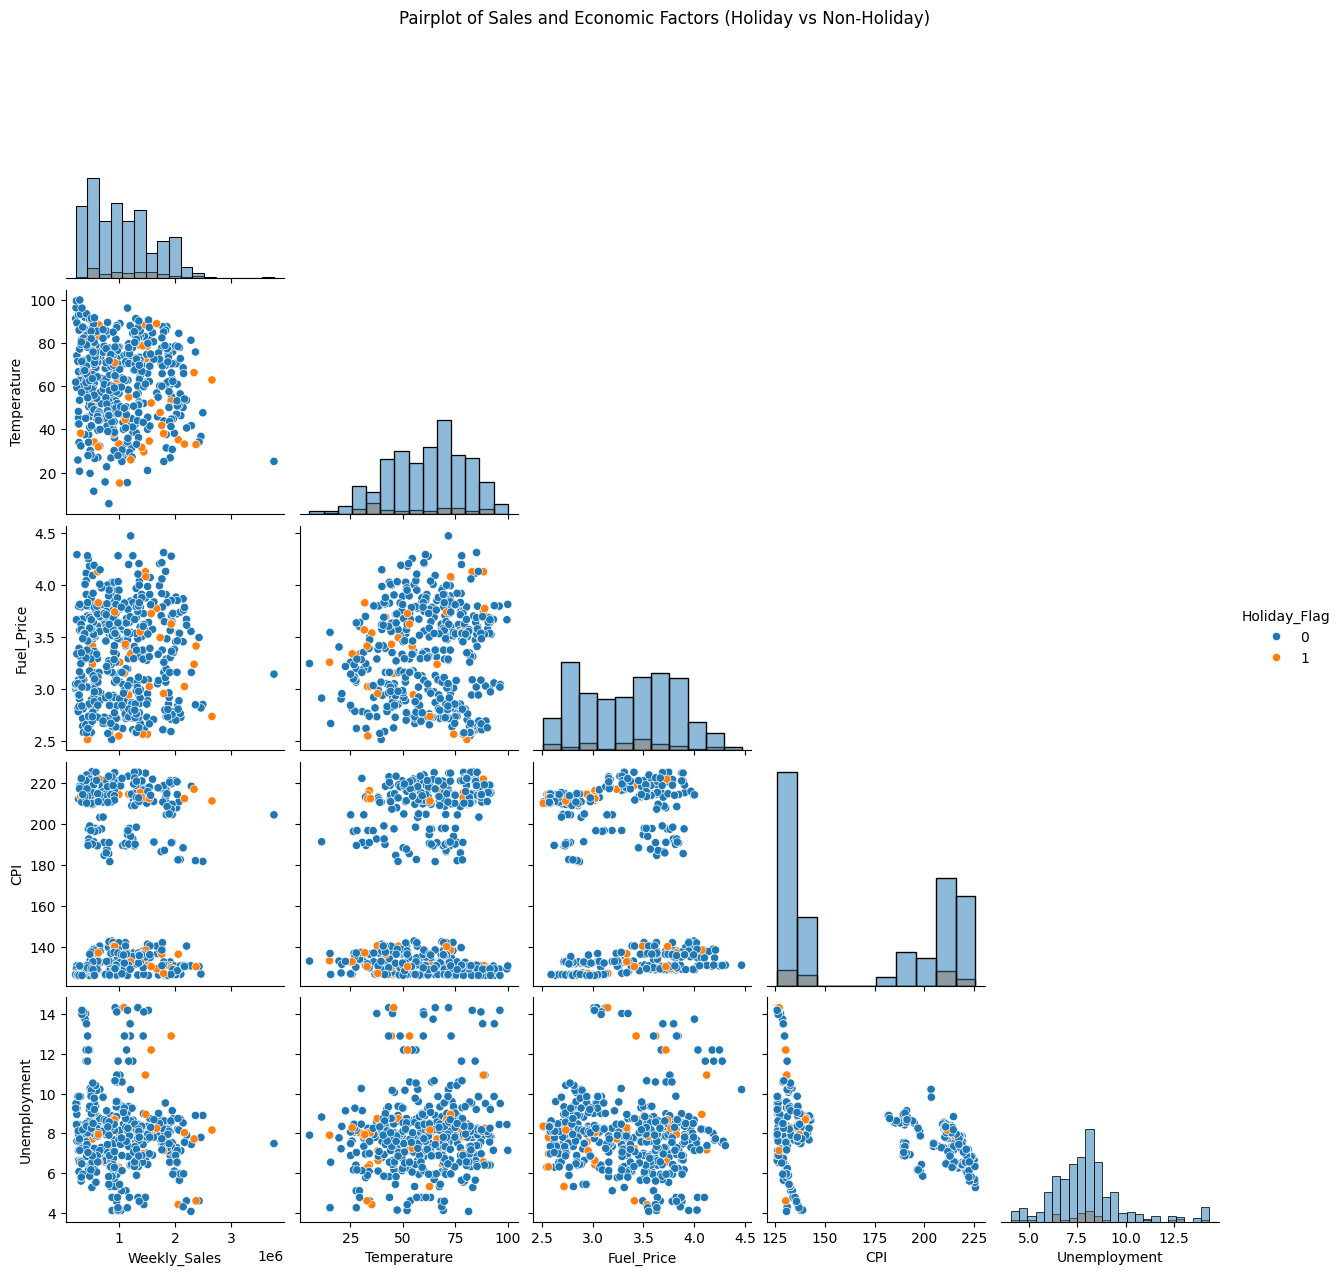

In [125]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Walmart.csv")

pairplot_df = df[[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Holiday_Flag"
]]

pairplot_sample = pairplot_df.sample(500, random_state=42)

sns.pairplot(
    pairplot_sample,
    vars=["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"],
    hue="Holiday_Flag",
    diag_kind="hist",
    corner=True
)

plt.suptitle("Pairplot of Sales and Economic Factors (Holiday vs Non-Holiday)", y=1.02)

plt.show()

The pairplot illustrates the relationships between weekly sales and key explanatory variables, including temperature, fuel price, CPI, and unemployment, with holiday periods highlighted. The results show that the relationships between weekly sales and individual predictors are generally weak and non-linear, as indicated by the dispersed distribution of points. This suggests that no single variable strongly determines sales performance, and that sales are influenced by a combination of factors. Holiday periods, highlighted in orange, show slightly higher and more variable sales values, indicating that holidays contribute to increased demand. Additionally, CPI exhibits clustered patterns, reflecting different economic conditions across the dataset. Overall, the pairplot supports the use of more advanced models, such as Random Forest, which can capture complex and non-linear relationships between variables.

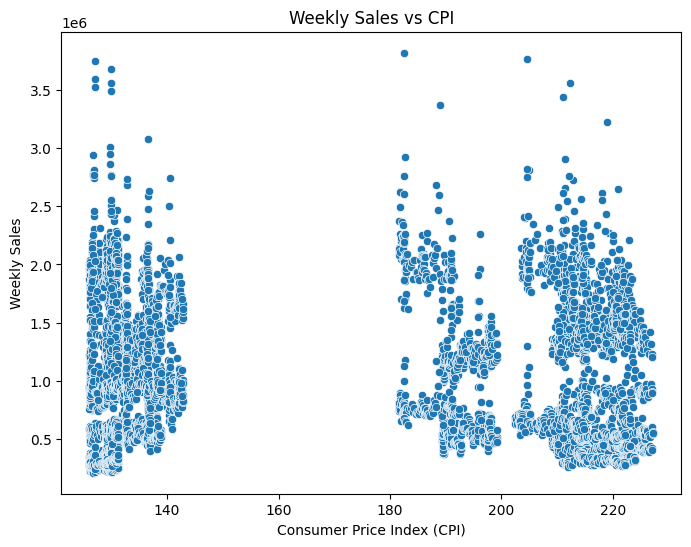

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="CPI", y="Weekly_Sales")

plt.title("Weekly Sales vs CPI")
plt.xlabel("Consumer Price Index (CPI)")
plt.ylabel("Weekly Sales")

plt.show()

The scatter plot of Weekly Sales against CPI suggests that the relationship between the two variables is weak and non-linear. Sales values are distributed across multiple CPI levels, with visible clustering patterns that may reflect different economic periods within the dataset. This indicates that CPI may have some influence on sales, but it is unlikely to act as a strong standalone predictor. Instead, its effect is likely to interact with other variables in the forecasting model.

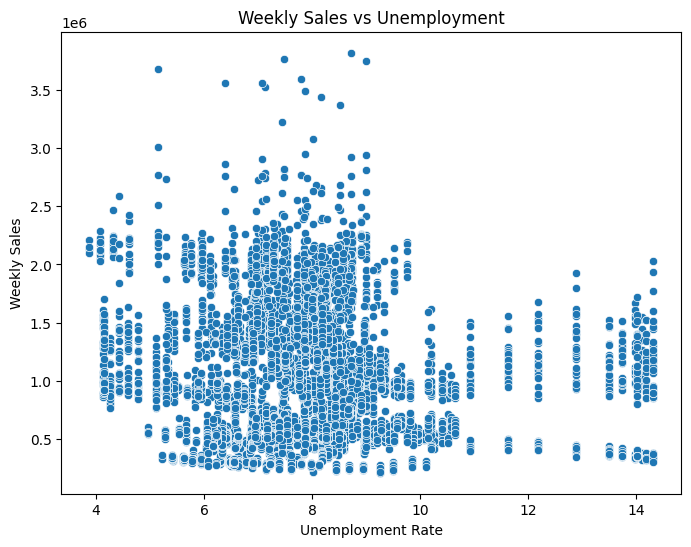

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Unemployment", y="Weekly_Sales")

plt.title("Weekly Sales vs Unemployment")
plt.xlabel("Unemployment Rate")
plt.ylabel("Weekly Sales")

plt.show()

The relationship between weekly sales and unemployment appears weak, with a slight negative trend indicating that higher unemployment levels may be associated with reduced sales. However, the scattered distribution suggests that unemployment is not a strong standalone predictor and likely interacts with other variables in influencing sales performance.

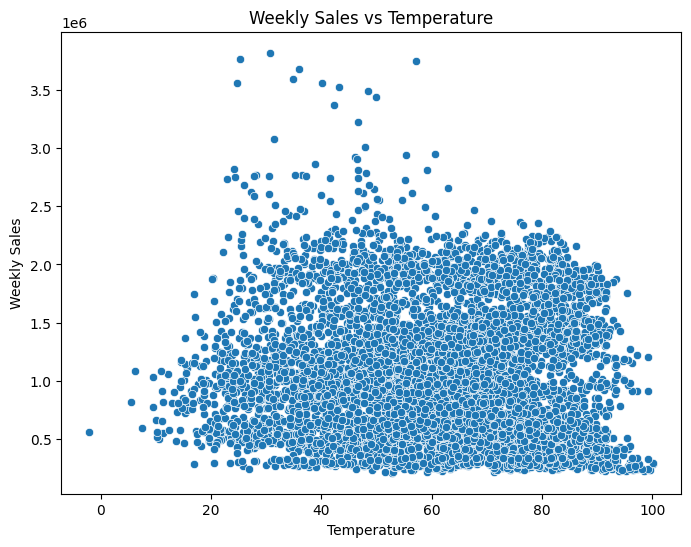

In [128]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Temperature", y="Weekly_Sales")

plt.title("Weekly Sales vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")

plt.show()

The scatter plot between weekly sales and temperature shows no clear relationship, with sales values widely dispersed across all temperature ranges. This indicates that temperature does not have a significant direct impact on sales and is unlikely to be a strong predictor in the forecasting model.

## 12 Sales Trend Over Time

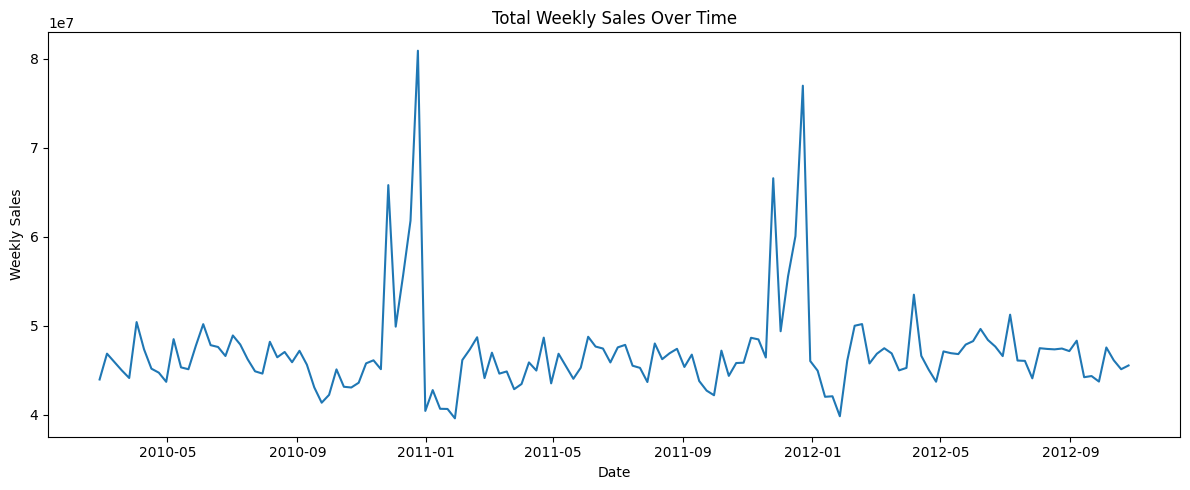

In [130]:
plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

The weekly sales series shows relatively stable baseline performance with noticeable seasonal peaks, particularly toward the end of each year. These spikes suggest that sales are strongly influenced by recurring seasonal demand patterns.

## Rolling Average Trend

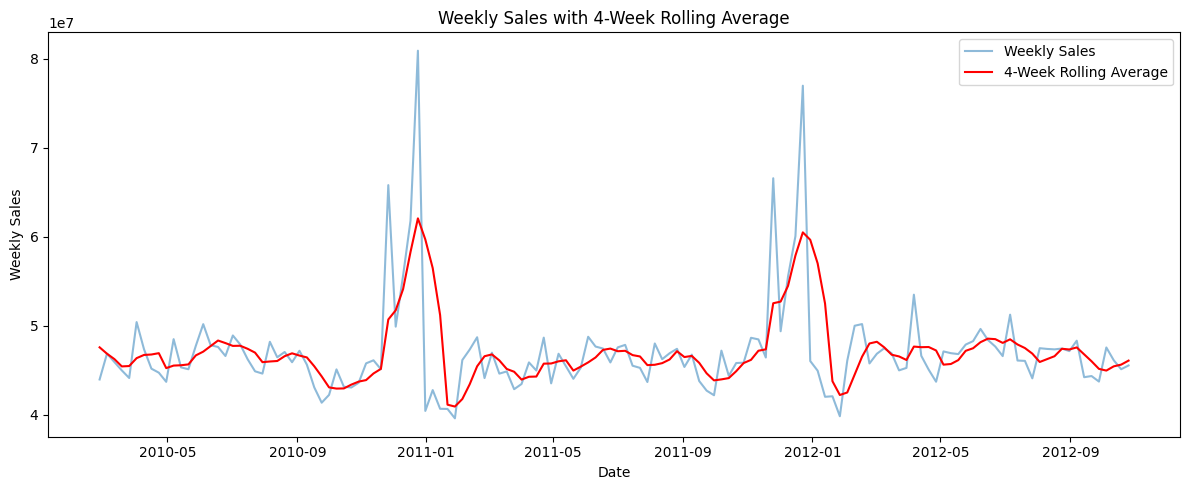

In [131]:
plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'], alpha=0.5, label='Weekly Sales')
plt.plot(weekly_total['Date'], weekly_total['Rolling_4wk'], color='red', label='4-Week Rolling Average')
plt.title("Weekly Sales with 4-Week Rolling Average")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

The 4-week rolling average smooths short-term fluctuations and highlights the underlying trend in sales. It confirms that the sales series is largely stable over time, with clear seasonal peaks between October and December followed by a sharp drop in January.

## Monthly Seasonality

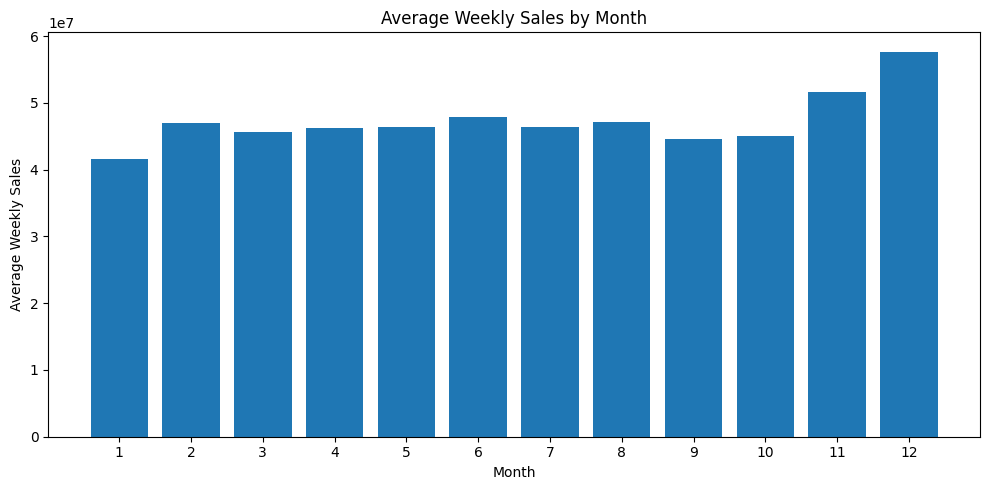

In [132]:
monthly_avg = (
    weekly_total
    .groupby('Month')['Weekly_Sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(monthly_avg['Month'], monthly_avg['Weekly_Sales'])
plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

Average weekly sales by month indicate moderate but consistent seasonality. December records the highest sales levels, while January experiences a decline, reflecting typical post-holiday contraction in consumer spending.

## Holiday Effect Analysis

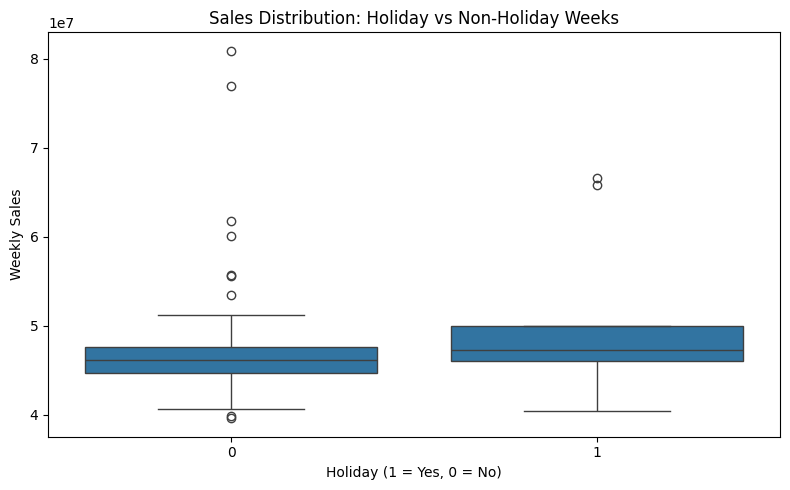

In [133]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=weekly_total)
plt.title("Sales Distribution: Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday (1 = Yes, 0 = No)")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

The distribution of weekly sales is positively skewed, with most observations concentrated at moderate values and a smaller number of high-value observations extending the distribution to the right. These extreme values likely correspond to holiday or seasonal peaks.

## Correlation Analysis

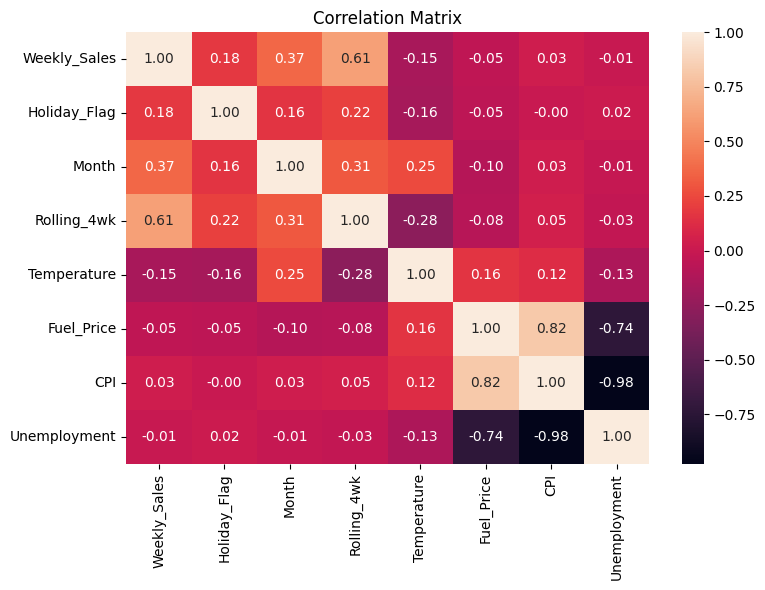

In [134]:
corr = weekly_total[['Weekly_Sales','Holiday_Flag','Month','Rolling_4wk','Temperature','Fuel_Price','CPI','Unemployment']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation matrix reveals that the rolling 4-week average has the strongest relationship with weekly sales, indicating that recent trends are highly predictive. Seasonal and event-based variables also contribute to variation in sales, while macroeconomic indicators show weaker but still relevant relationships.

## 13 Linear forcasting models 

In [135]:
print(type(weekly_total))
print(weekly_total.head())

<class 'pandas.core.frame.DataFrame'>
        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price         CPI  \
3 2010-02-26   43968571.13             0    39.243556    2.683933  167.909657   
4 2010-03-05   46871470.30             0    42.917333    2.731200  167.947628   
5 2010-03-12   45925396.51             0    47.432444    2.774422  167.985598   
6 2010-03-19   44988974.64             0    49.954222    2.817089  167.930427   
7 2010-03-26   44133961.05             0    48.473556    2.824111  167.859731   

   Unemployment  Month  Year  Week   Rolling_4wk        Lag_1        Lag_2  \
3      8.619311      2  2010     8  4.758325e+07  48276993.78  48336677.63   
4      8.619311      3  2010     9  4.686343e+07  43968571.13  48276993.78   
5      8.619311      3  2010    10  4.626061e+07  46871470.30  43968571.13   
6      8.619311      3  2010    11  4.543860e+07  45925396.51  46871470.30   
7      8.619311      3  2010    12  4.547995e+07  44988974.64  45925396.51   

   Tim

In [136]:
print(weekly_total.columns.tolist())

['Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year', 'Week', 'Rolling_4wk', 'Lag_1', 'Lag_2', 'Time_Index']


In [137]:
weekly_total['Lag_4'] = weekly_total['Weekly_Sales'].shift(4)
weekly_total['Lag_12'] = weekly_total['Weekly_Sales'].shift(12)

weekly_total = weekly_total.dropna().reset_index(drop=True)

In [138]:
features = ["Lag_1", "Lag_2", "Rolling_4wk", "Time_Index", "Month"]

X = weekly_total[features]
y = weekly_total["Weekly_Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (128, 5)
Target shape: (128,)


In [139]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 102
Testing samples: 26


## Linear Regression 

In [140]:
# =========================
# STEP 3 — Linear Regression
# =========================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression Results")
print("MAE:", mae_lin)
print("RMSE:", rmse_lin)
print("R²:", r2_lin)

Linear Regression Results
MAE: 1528483.756819137
RMSE: 1955393.4086529138
R²: -0.33397714384152466


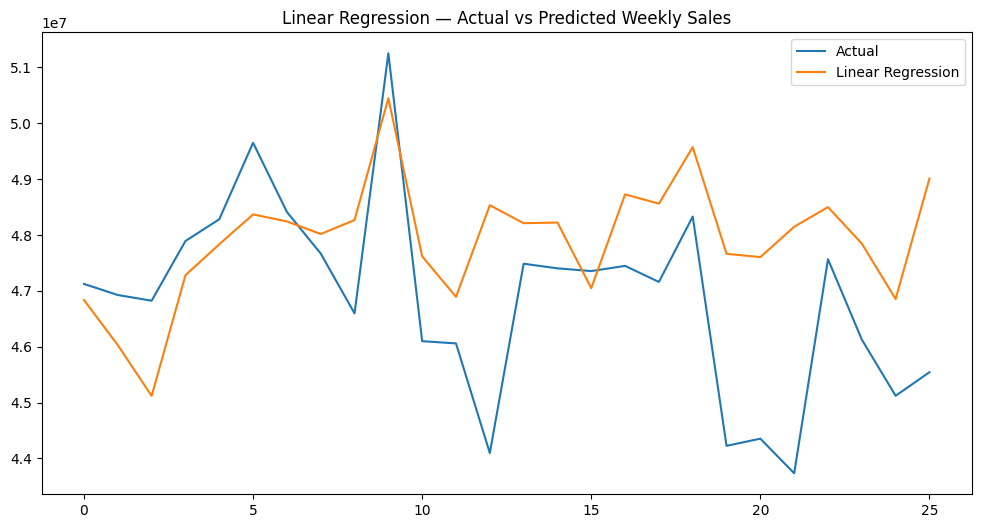

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lin, label="Linear Regression")
plt.legend()
plt.title("Linear Regression — Actual vs Predicted Weekly Sales")
plt.show()

## Ridge Regression 

In [142]:
# =========================
# STEP 4 — Ridge Regression
# =========================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("scaler", StandardScaler()),  # important for Ridge
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R²:", r2_ridge)

Ridge Regression Results
MAE: 1546204.9884253116
RMSE: 1972112.306463271
R²: -0.3568860610992537


In [143]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [144]:
y_pred_ridge = ridge_model.predict(X_test)

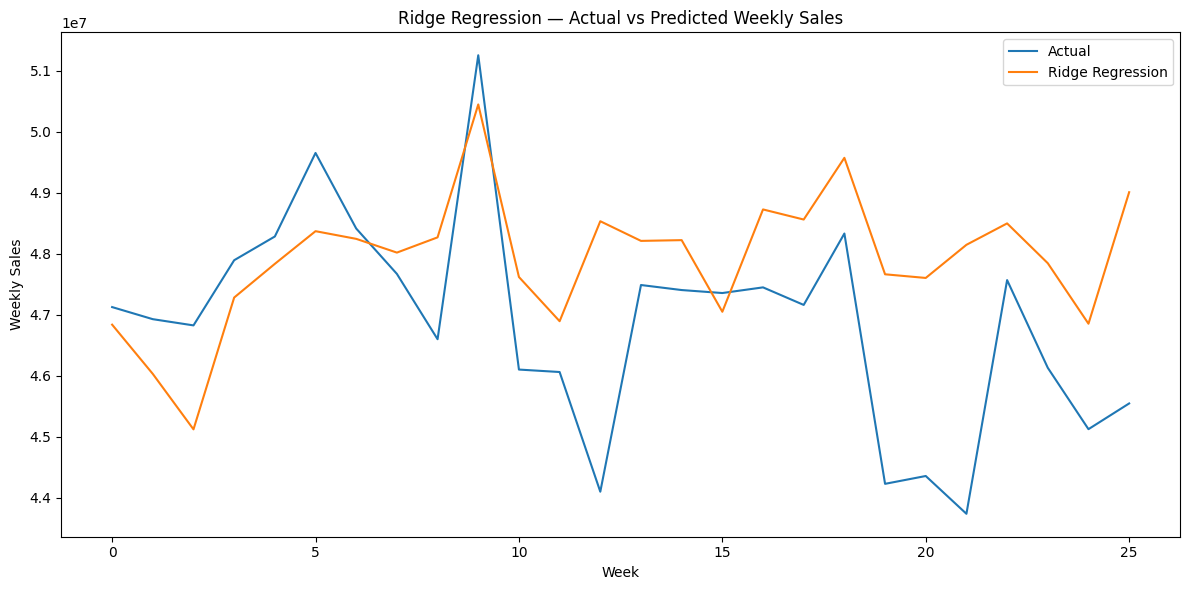

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_ridge, label="Ridge Regression")
plt.legend()
plt.title("Ridge Regression — Actual vs Predicted Weekly Sales")
plt.xlabel("Week")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

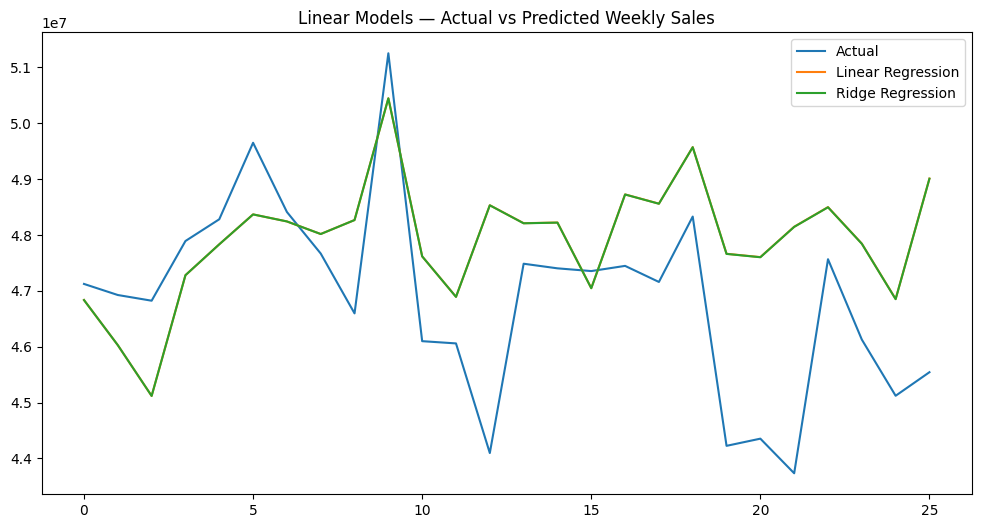

In [146]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lin, label="Linear Regression")
plt.plot(y_pred_ridge, label="Ridge Regression")
plt.legend()
plt.title("Linear Models — Actual vs Predicted Weekly Sales")
plt.show()

Linear models were selected as a baseline forecasting approach due to their simplicity, interpretability, and widespread use in time-series prediction tasks. Lagged sales variables were used as predictors to capture temporal dependencies, reflecting the assumption that recent demand influences future performance.

Both linear models produced relatively smooth forecasts and struggled to capture sharp fluctuations in weekly sales. The negative R² values indicate that the models explain less variation than a simple mean-based prediction, suggesting that weekly demand patterns are not adequately represented by a purely linear relationship.

Overall, while linear models provide a useful baseline and offer interpretability, they appear insufficient for modelling the full complexity of aggregated retail demand. This motivates the evaluation of non-linear approaches in the following section.


In [147]:
# =========================
# STEP 5 — Linear Model Comparison
# =========================

import pandas as pd

linear_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MAE": [mae_lin, mae_ridge],
    "RMSE": [rmse_lin, rmse_ridge],
    "R2": [r2_lin, r2_ridge]
})

linear_results

,Model,MAE,RMSE,R2
0,Linear Regression,1.528484e+06,1.955393e+06,-0.333977
1,Ridge Regression,1.546205e+06,1.972112e+06,-0.356886


In [148]:
linear_results.sort_values(by="RMSE")

,Model,MAE,RMSE,R2
0,Linear Regression,1.528484e+06,1.955393e+06,-0.333977
1,Ridge Regression,1.546205e+06,1.972112e+06,-0.356886


Two linear forecasting models were evaluated: Linear Regression and Ridge Regression. Both models used lagged sales features to predict future weekly demand. Performance was assessed using MAE, RMSE, and R².

Ridge Regression achieved slightly lower error metrics than standard Linear Regression, indicating improved generalisation due to regularisation. This suggests that penalising large coefficients helps stabilise predictions when using correlated lag variables.

However, both models produce relatively smooth forecasts and struggle to capture sudden spikes in demand. This limitation indicates that retail sales behaviour is influenced by complex and potentially non-linear factors beyond simple linear relationships.

Although Random Forest performs best among the tested models, the relatively modest R² value indicates that substantial variability remains unexplained.

 ## 14 Non linear models 

The limitations of the linear models indicate that weekly sales behaviour is influenced by complex interactions and non-linear patterns. Therefore, a Random Forest model was selected to capture these relationships.

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive accuracy and reduce overfitting. Unlike linear models, it does not assume a fixed functional relationship between predictors and the target variable.

The Random Forest model achieved lower MAE and RMSE values than both linear models and produced a positive R² score. This indicates improved forecasting performance and suggests that non-linear patterns play a significant role in weekly sales dynamics.

The predicted values follow the overall pattern of actual sales more closely than the linear models, particularly during periods of rapid change. However, the model still fails to fully reproduce extreme peaks and troughs.



## Random Forrest model 

In [149]:
# =========================
# STEP 6 — Random Forest
# =========================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 1376636.363186542
RMSE: 1630086.3713038287
R²: 0.07295390783975964


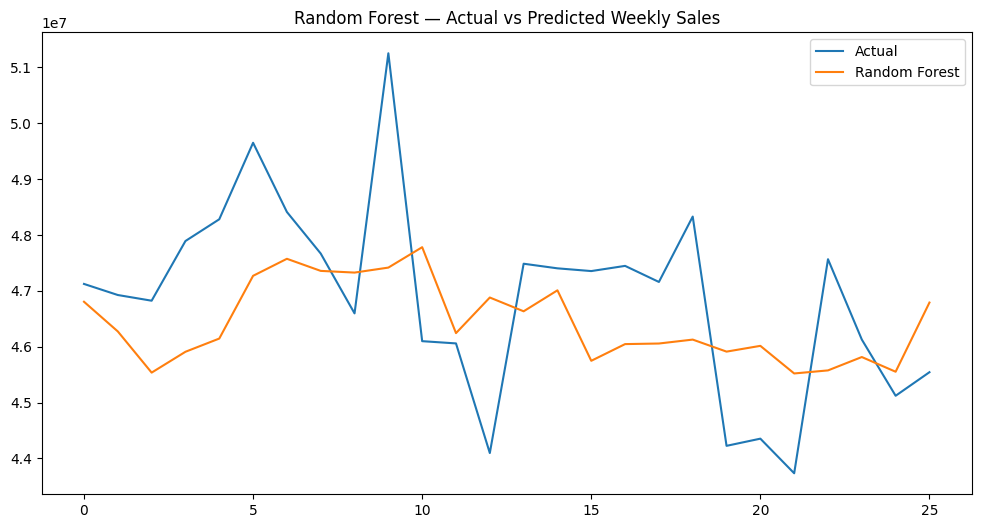

In [150]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_rf, label="Random Forest")
plt.legend()
plt.title("Random Forest — Actual vs Predicted Weekly Sales")
plt.show()

## GBM Gradient Boost regressor 

In [151]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

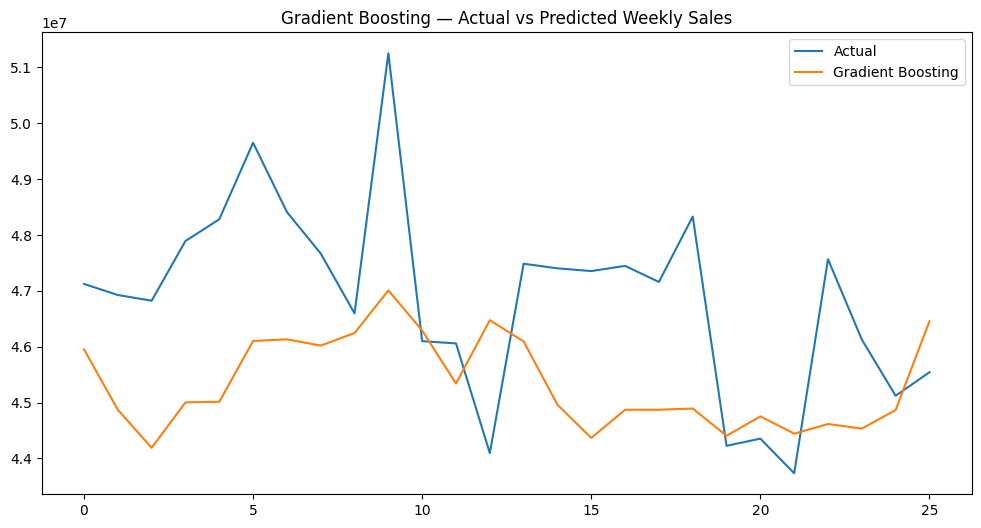

In [152]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_gbr, label="Gradient Boosting")
plt.legend()
plt.title("Gradient Boosting — Actual vs Predicted Weekly Sales")
plt.show()

In [153]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print("GBR MAE:", mae_gbr)
print("GBR RMSE:", rmse_gbr)

GBR MAE: 1903473.3172361203
GBR RMSE: 2233649.3798996406


## Support Vector Regression

In [154]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=1000,        # MUCH stronger
        gamma=0.01,    # Controls flexibility
        epsilon=0.1
    ))
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

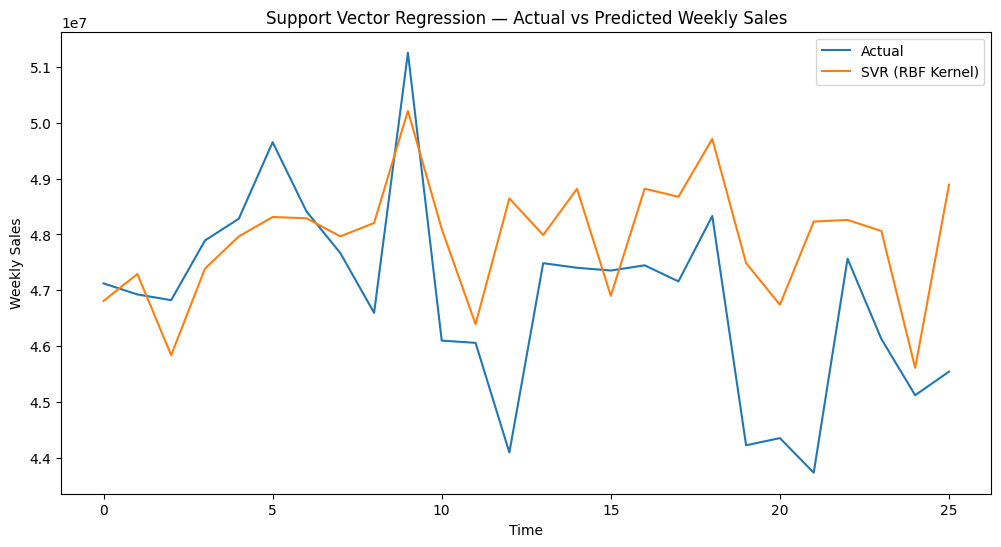

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_svr, label="SVR (RBF Kernel)")

plt.legend()
plt.title("Support Vector Regression — Actual vs Predicted Weekly Sales")
plt.xlabel("Time")
plt.ylabel("Weekly Sales")

plt.show()

In [156]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

## MLP Regressor 

In [157]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model = TransformedTargetRegressor(
    regressor=mlp_pipeline,
    transformer=StandardScaler()
)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

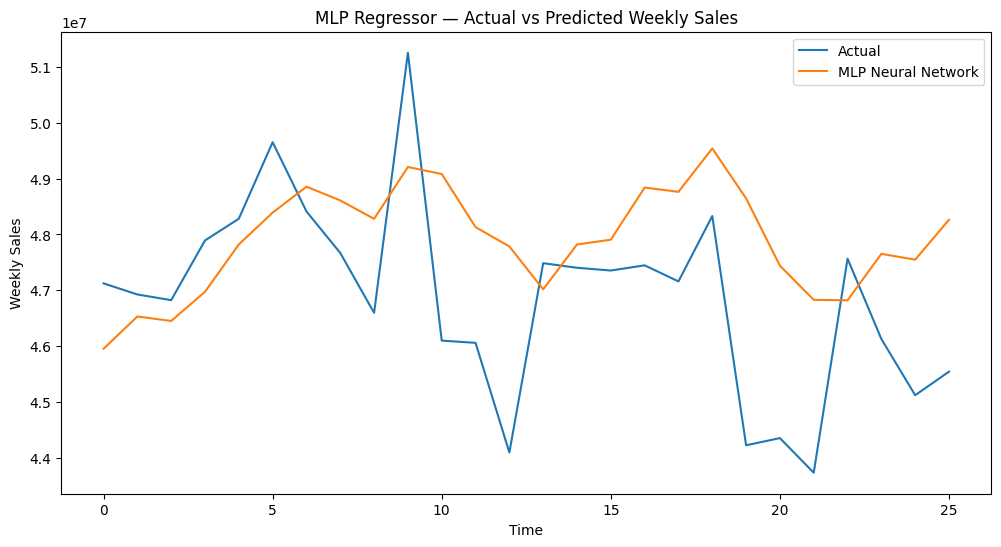

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_mlp, label="MLP Neural Network")

plt.legend()
plt.title("MLP Regressor — Actual vs Predicted Weekly Sales")
plt.xlabel("Time")
plt.ylabel("Weekly Sales")

plt.show()

In [159]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Results")
print("MAE:", mae_mlp)
print("RMSE:", rmse_mlp)
print("R²:", r2_mlp)

MLP Results
MAE: 1618753.135409153
RMSE: 1967502.8021175524
R²: -0.3505504557361747


## model comparrison non linear to weekly sales 

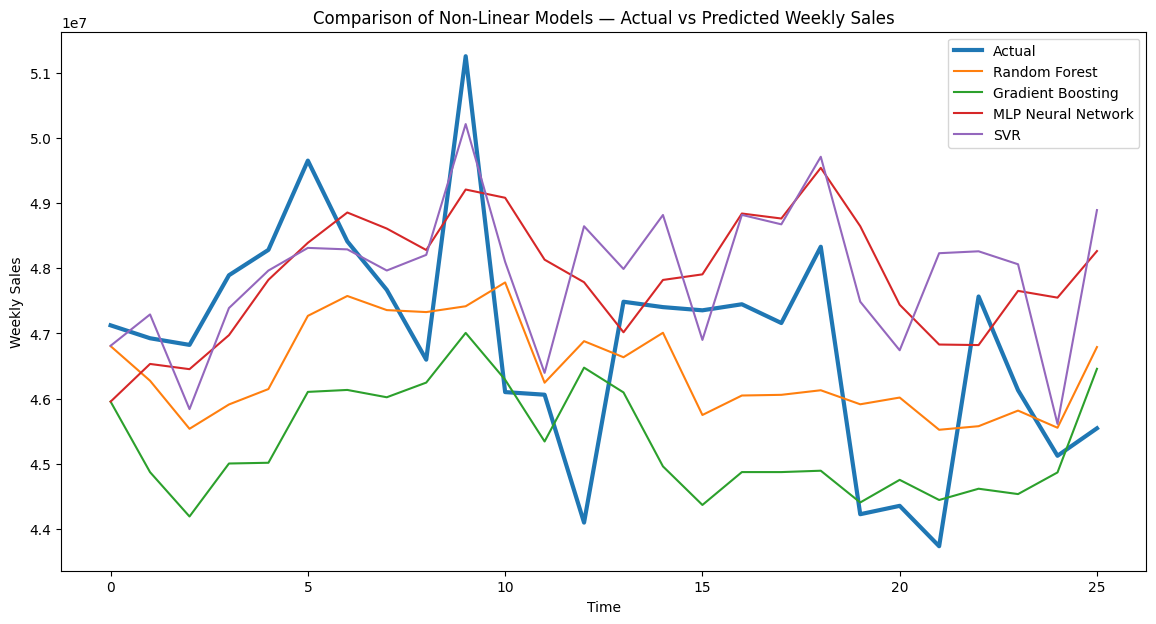

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(y_test.values, label="Actual", linewidth=3)

plt.plot(y_pred_rf, label="Random Forest")
plt.plot(y_pred_gbr, label="Gradient Boosting")
plt.plot(y_pred_mlp, label="MLP Neural Network")
plt.plot(y_pred_svr, label="SVR")

plt.legend()
plt.title("Comparison of Non-Linear Models — Actual vs Predicted Weekly Sales")
plt.xlabel("Time")
plt.ylabel("Weekly Sales")

plt.show()

## Metrics comparisent table 

In [161]:
print("RF  MAE:", mae_rf,  "RMSE:", rmse_rf)
print("GBR MAE:", mae_gbr, "RMSE:", rmse_gbr)
print("MLP MAE:", mae_mlp, "RMSE:", rmse_mlp)
print("SVR MAE:", mae_svr, "RMSE:", rmse_svr)

RF  MAE: 1376636.363186542 RMSE: 1630086.3713038287
GBR MAE: 1903473.3172361203 RMSE: 2233649.3798996406
MLP MAE: 1618753.135409153 RMSE: 1967502.8021175524
SVR MAE: 1423681.4225345452 RMSE: 1887674.617631218


MAE Comparisent gragh 

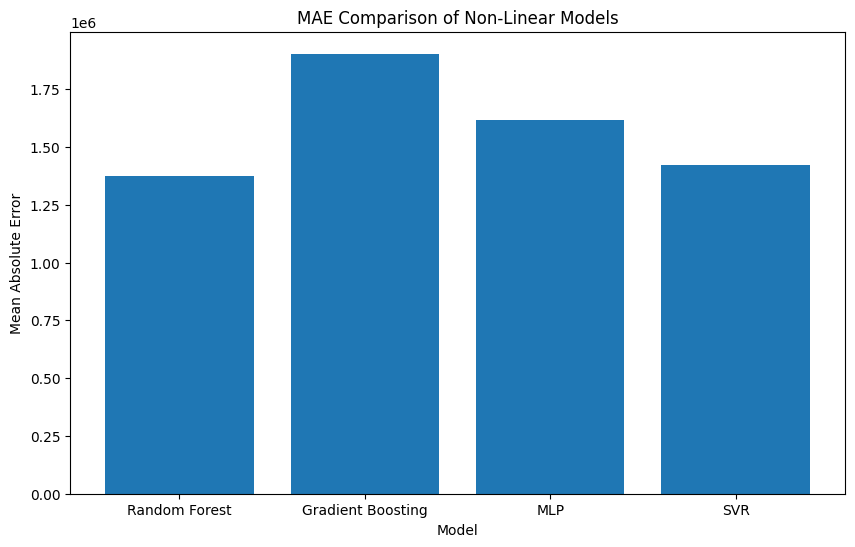

In [162]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Gradient Boosting", "MLP", "SVR"]
mae_scores = [mae_rf, mae_gbr, mae_mlp, mae_svr]

plt.figure(figsize=(10,6))
plt.bar(models, mae_scores)

plt.title("MAE Comparison of Non-Linear Models")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Model")

plt.show()

RMSE Comparison  Gragh 

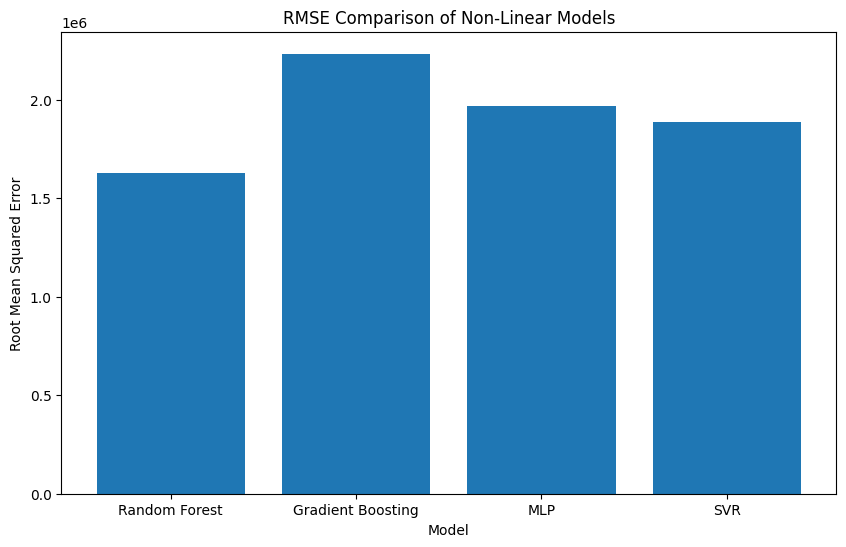

In [163]:
rmse_scores = [rmse_rf, rmse_gbr, rmse_mlp, rmse_svr]

plt.figure(figsize=(10,6))
plt.bar(models, rmse_scores)

plt.title("RMSE Comparison of Non-Linear Models")
plt.ylabel("Root Mean Squared Error")
plt.xlabel("Model")

plt.show()

In [164]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [165]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day

In [166]:
df = df.drop("Date", axis=1)

In [167]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

In [168]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [169]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [170]:
y_pred_rf = rf_model.predict(X_test)

In [171]:
# Calculate residuals (prediction errors)
residuals_rf = y_test - y_pred_rf

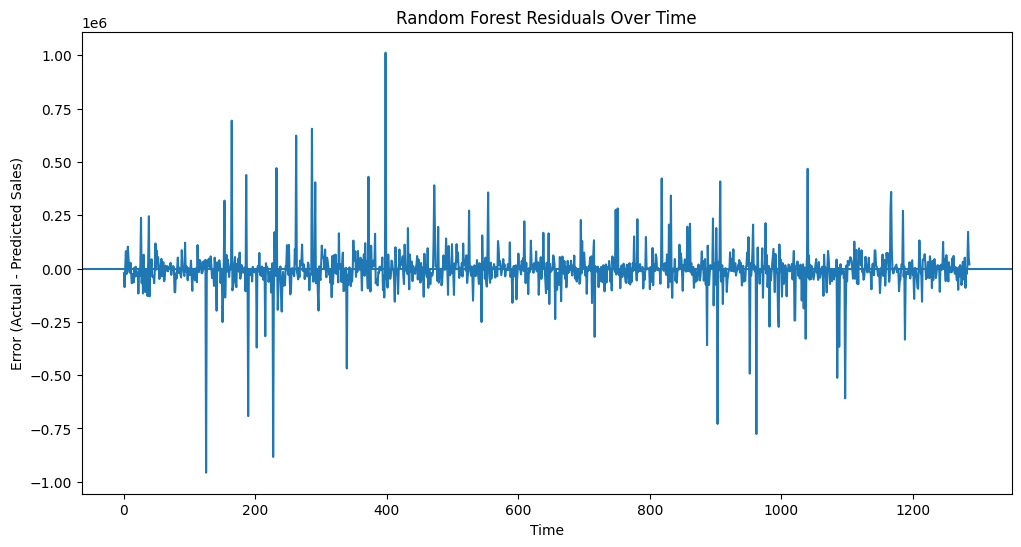

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(residuals_rf.values)

plt.axhline(0)

plt.title("Random Forest Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Error (Actual - Predicted Sales)")

plt.show()

The residual plot illustrates the prediction errors of the Random Forest model, calculated as the difference between actual and predicted weekly sales. Ideally, residuals should be randomly distributed around zero, indicating that the model does not consistently overestimate or underestimate values. In this case, most residuals are clustered near the zero line, suggesting that the model generally produces accurate predictions for typical sales levels. The lack of a visible trend or pattern indicates that the model does not suffer from systematic bias. However, several large positive and negative spikes are present, representing weeks where prediction errors are significantly higher. These deviations likely correspond to unusual demand patterns or external factors not fully captured by the model. Overall, the residual distribution indicates that the model performs reliably for normal sales behaviour but is less accurate during periods of extreme variation.

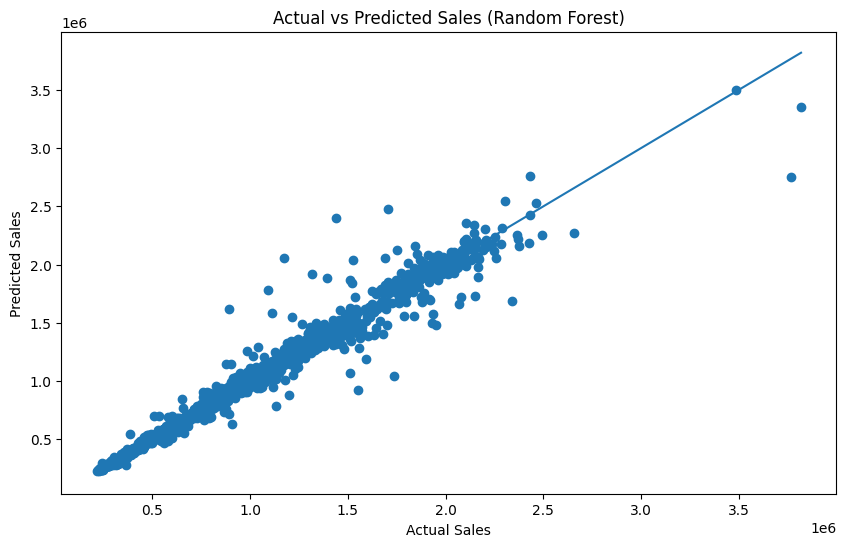

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.title("Actual vs Predicted Sales (Random Forest)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()

Actual vs Predicted Sales Analysis

The Actual vs Predicted plot illustrates the relationship between the observed weekly sales and the values predicted by the Random Forest model. The majority of data points are closely aligned along the diagonal reference line, indicating a strong agreement between predicted and actual values. This suggests that the model is effective in capturing the overall sales patterns within the dataset.

However, some dispersion is visible, particularly at higher sales values, where predictions deviate further from the actual values. This indicates that the model is less accurate when forecasting extreme sales levels, likely due to the increased variability during peak demand periods such as holidays or promotional events.

Overall, the plot demonstrates that the Random Forest model provides a good level of predictive accuracy, with most errors being relatively small, while highlighting some limitations in handling high-value outliers.